Module importing

In [3]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from lstm_unet import lstm_unet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

In [5]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = ["AF"])
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [10,10,10,10],
            "Kernel decoder":       [6,6,6,6],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = lstm_unet(para = para)
model.structure_calculate(True)
y = model(dataset[1][0].unsqueeze(1))
plt.plot(y.cpu().detach().numpy().flatten())

plt.show()

0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_30872\2002767544.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = ["AF"])


IndexError: list index out of range

Training

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [10,10,10,10],
            "Kernel decoder":       [6,6,6,6],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = lstm_unet(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.MSELoss())
builder.training(model,device,optimizer,num_epochs=900,batch=64,visualize=1)

True


d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([64, 1, 1, 800])) that is different to the input size (torch.Size([64, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([63, 1, 1, 800])) that is different to the input size (torch.Size([63, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Iteration: 1/900. loss_train: 0.3506964147090912. loss_val: 0
Iteration: 2/900. loss_train: 0.3217560350894928. loss_val: 0
Iteration: 3/900. loss_train: 0.30557844042778015. loss_val: 0
Iteration: 4/900. loss_train: 0.293184369802475. loss_val: 0
Iteration: 5/900. loss_train: 0.28843167424201965. loss_val: 0
Iteration: 6/900. loss_train: 0.28568968176841736. loss_val: 0
Iteration: 7/900. loss_train: 0.2828303873538971. loss_val: 0
Iteration: 8/900. loss_train: 0.28718647360801697. loss_val: 0
Iteration: 9/900. loss_train: 0.2770877778530121. loss_val: 0
Iteration: 10/900. loss_train: 0.27323031425476074. loss_val: 0
Iteration: 11/900. loss_train: 0.27795299887657166. loss_val: 0
Iteration: 12/900. loss_train: 0.2709987759590149. loss_val: 0
Iteration: 13/900. loss_train: 0.26965051889419556. loss_val: 0
Iteration: 14/900. loss_train: 0.26704806089401245. loss_val: 0
Iteration: 15/900. loss_train: 0.2600168287754059. loss_val: 0
Iteration: 16/900. loss_train: 0.26595500111579895. loss_

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_30096\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.9231201
Mean loss:  0.12220173
Min loss:  0.005024886
Number of test:  104


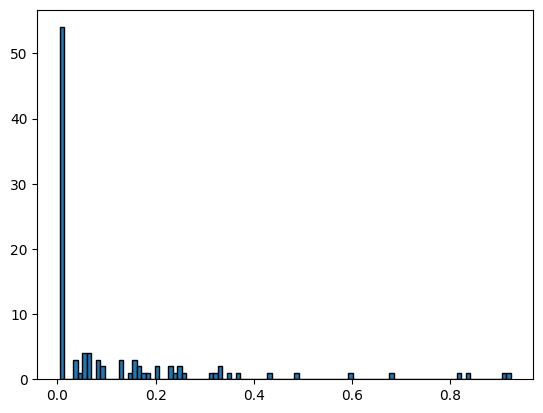

0.16040285


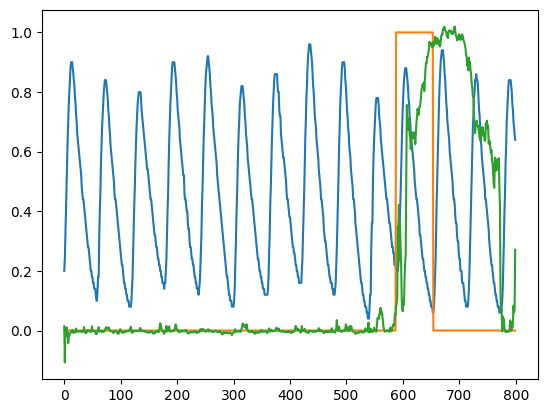

0.0069207847


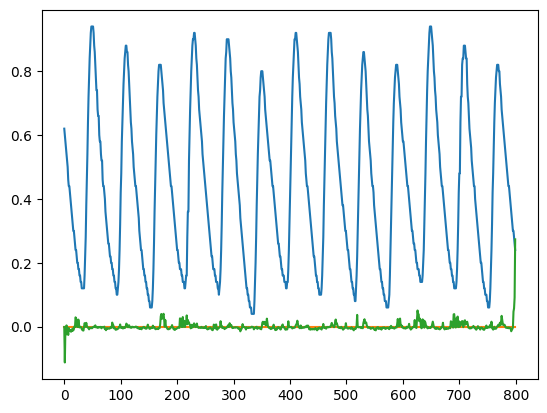

0.087804146


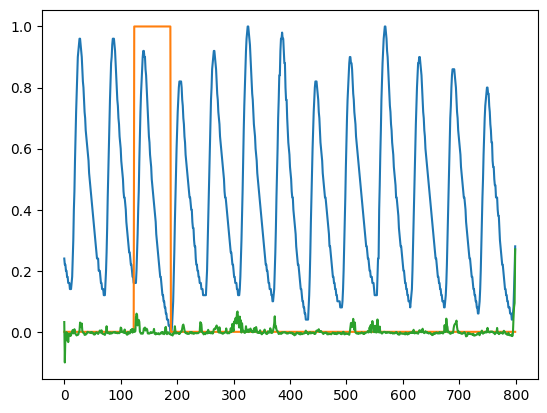

0.25026837


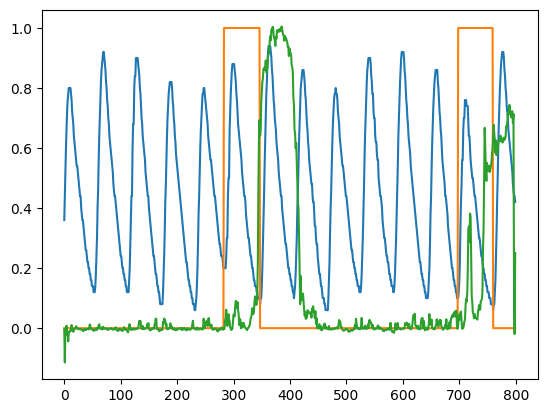

0.15915991


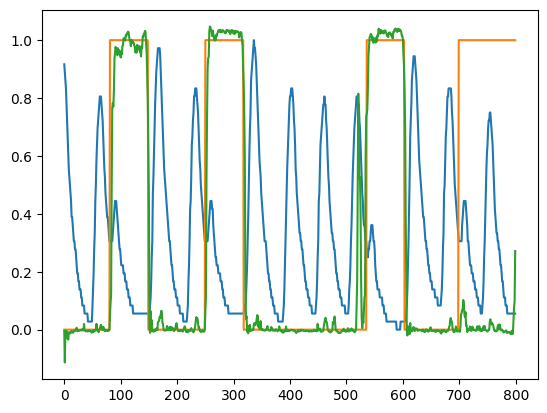

0.005905771


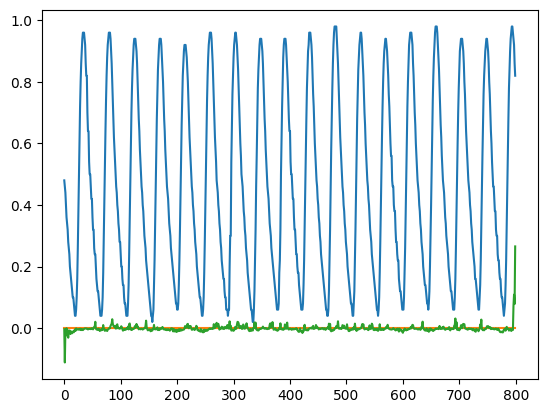

0.005794011


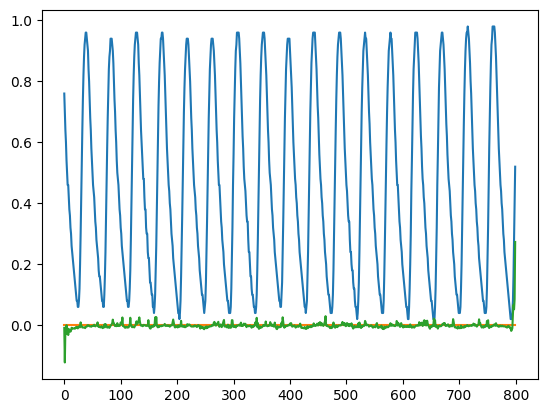

0.0063374257


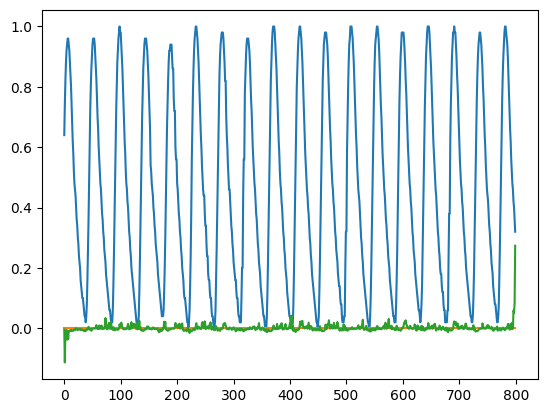

0.0056422935


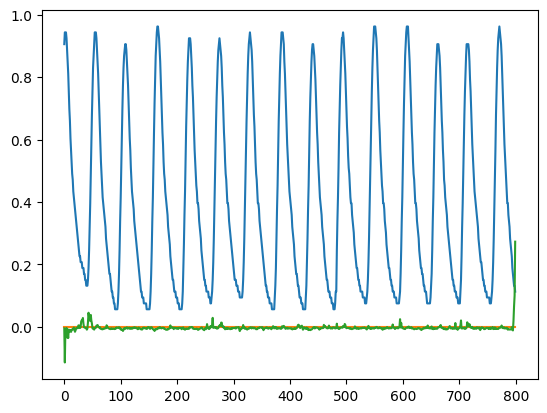

0.005556149


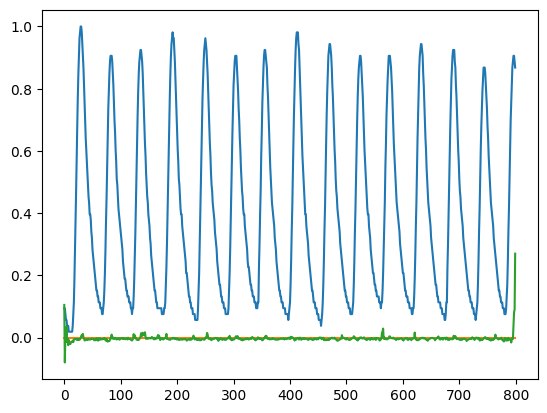

0.005492183


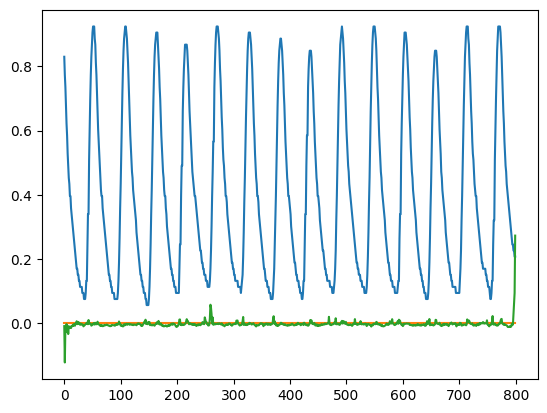

0.005329098


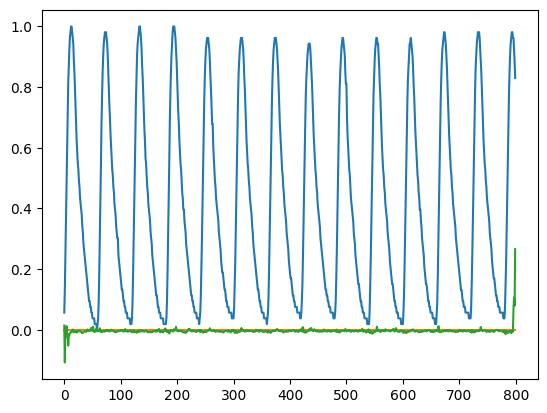

0.005701236


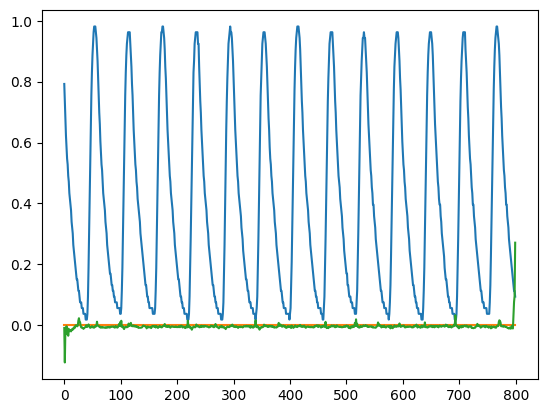

0.0063209687


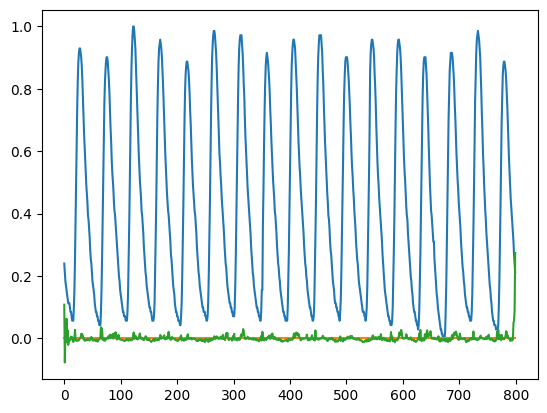

0.006667219


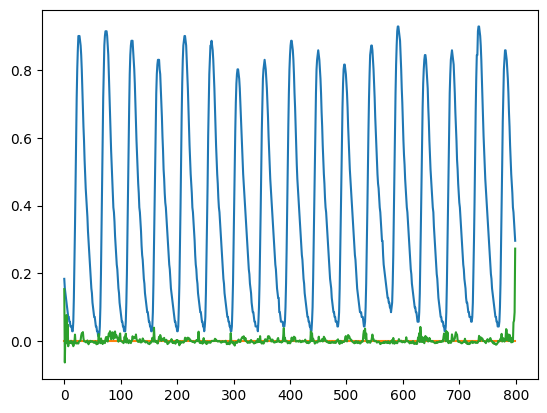

0.00649776


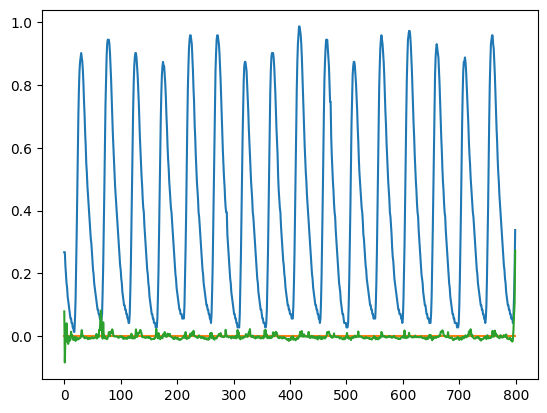

0.04488363


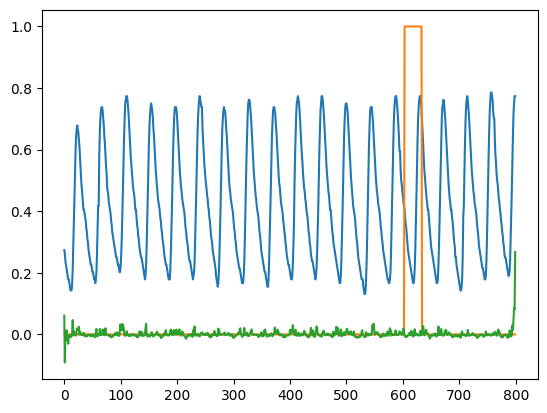

0.062364273


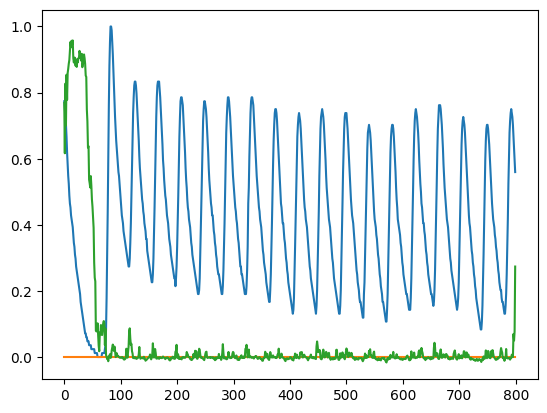

0.0072733676


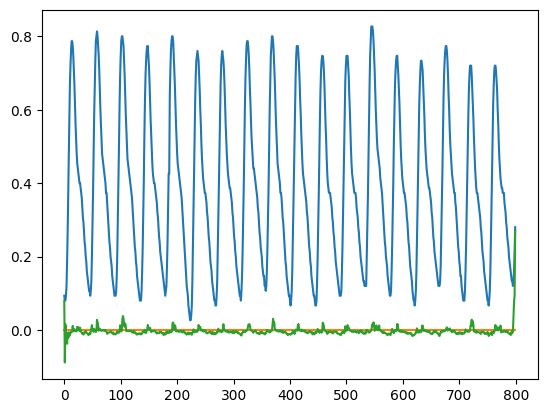

0.007839284


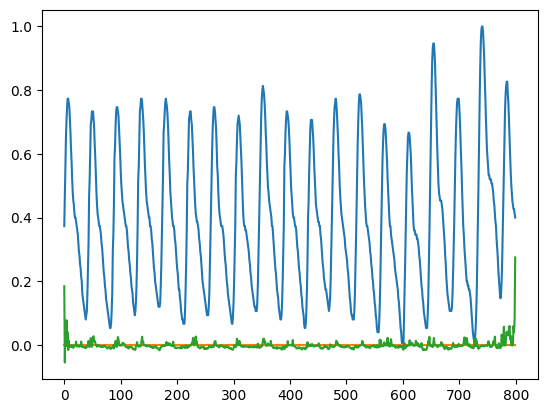

0.005086935


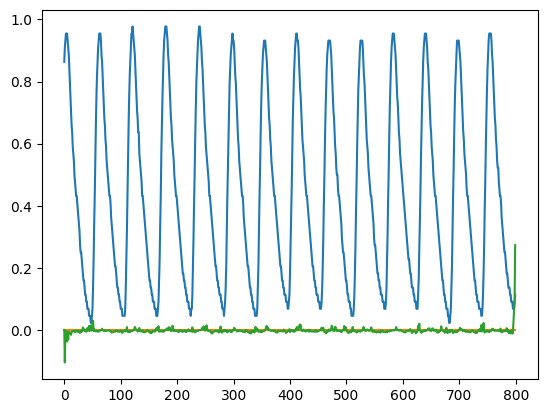

0.0050844443


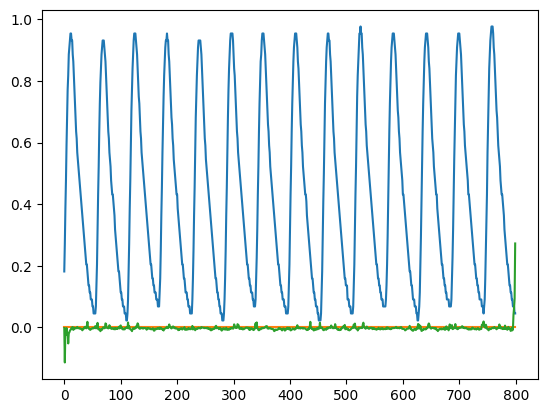

0.0052526775


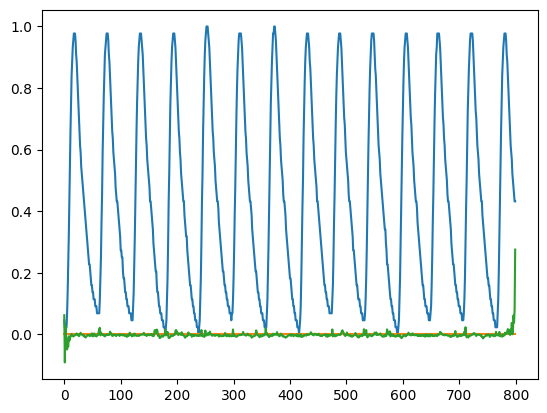

0.009779228


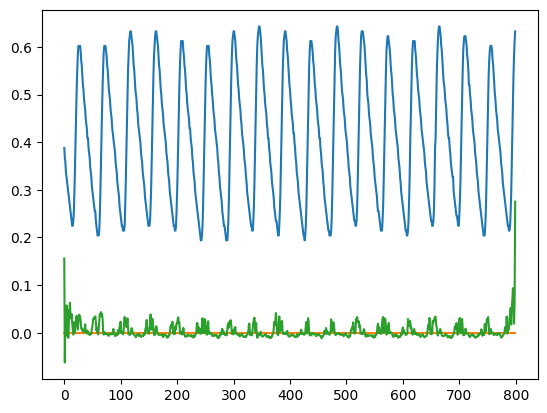

0.010196371


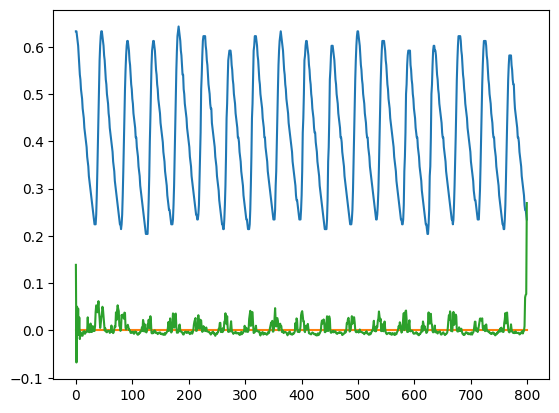

0.08172083


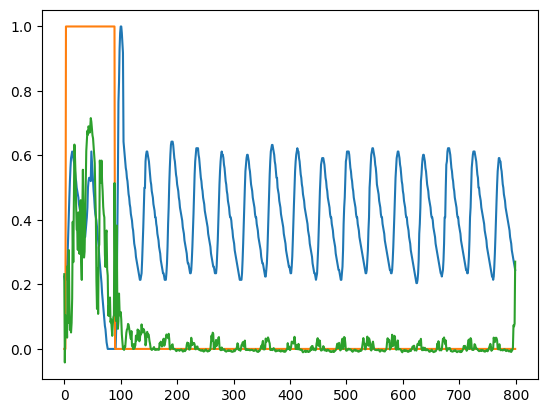

0.8395729


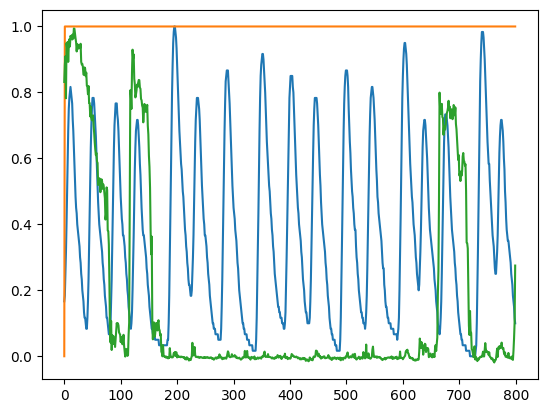

0.9111911


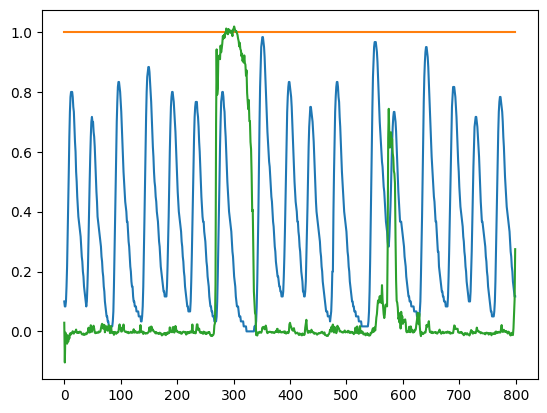

0.92311996


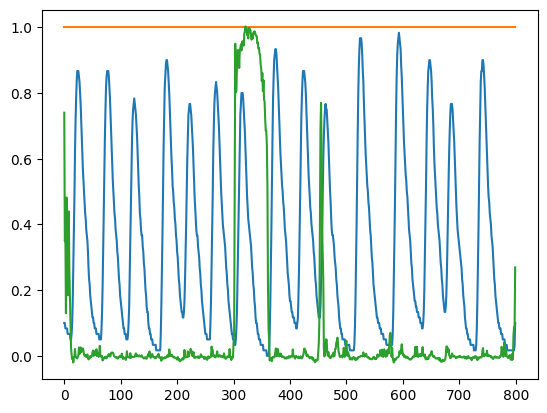

0.81979823


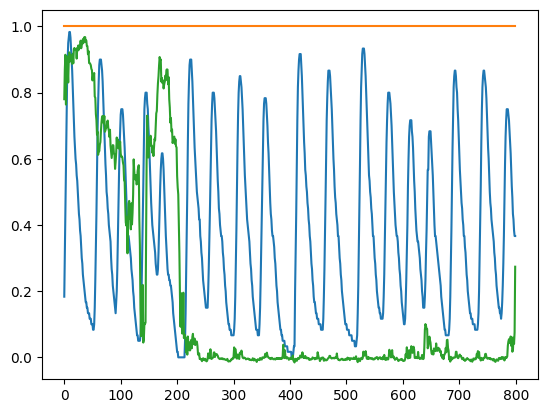

0.006024668


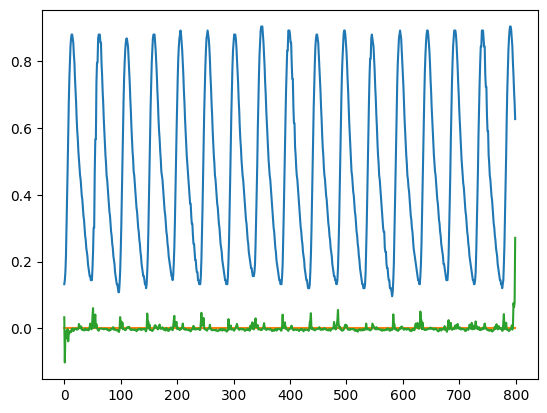

0.006583813


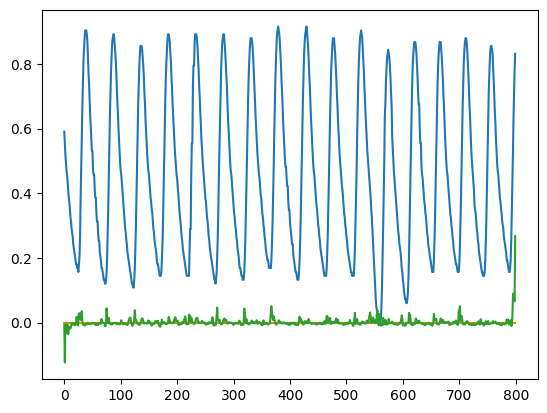

0.005923338


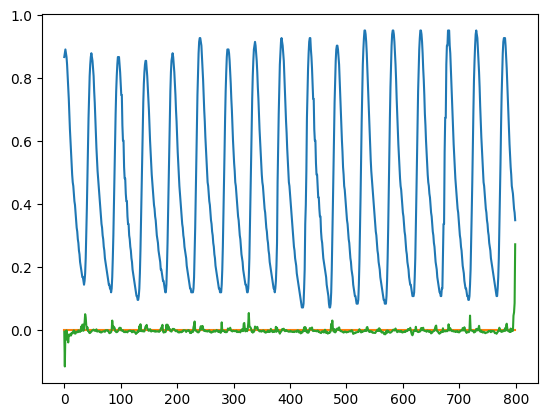

0.0057945536


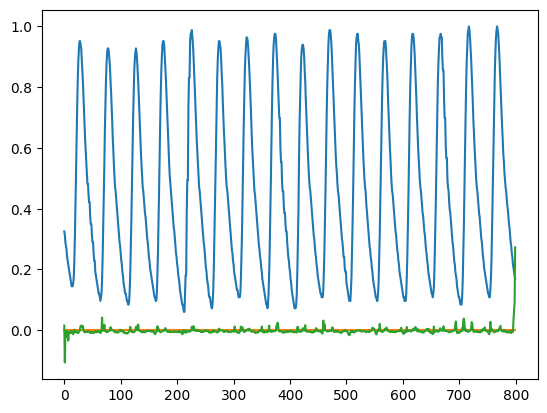

0.005774579


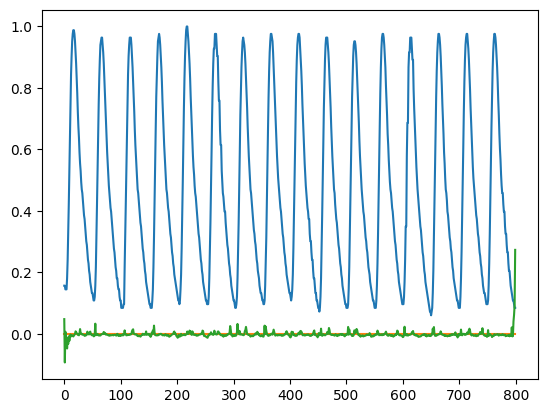

0.0064950753


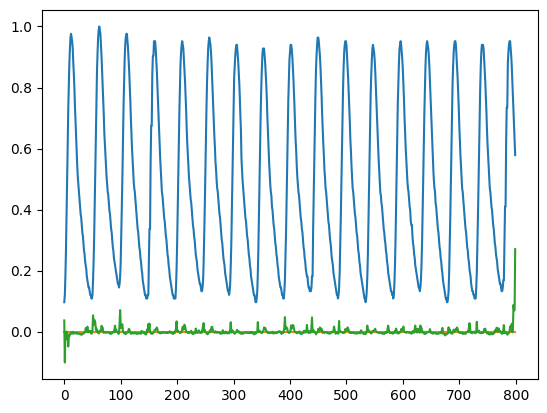

0.005772142


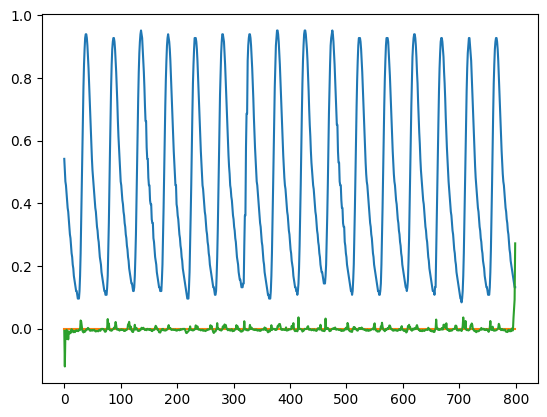

0.0061747325


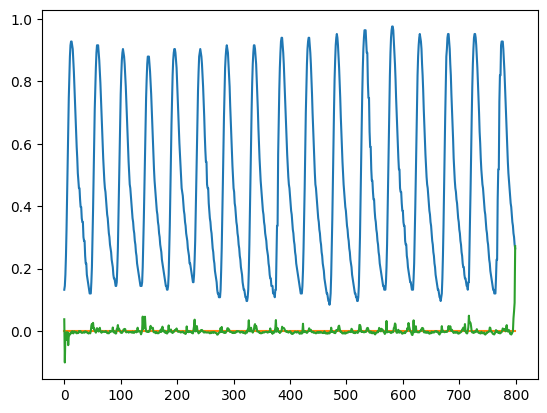

0.0059891553


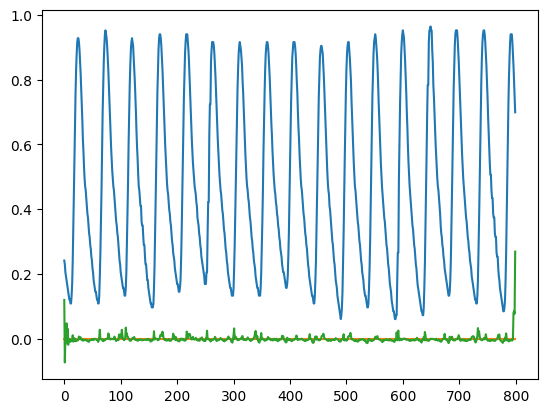

0.48577744


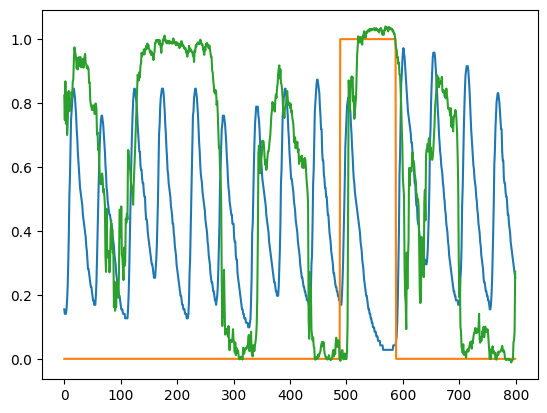

0.3519622


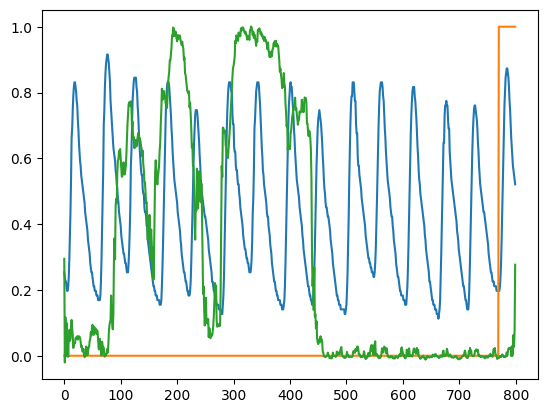

0.31434295


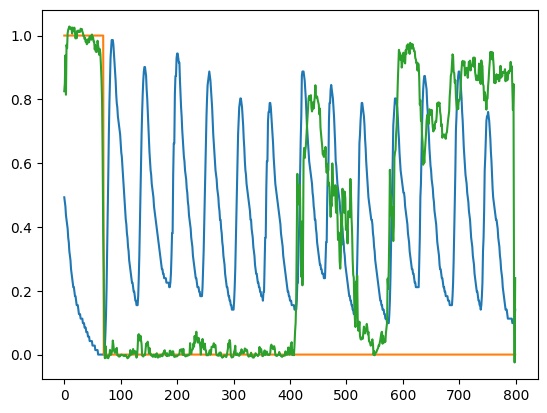

0.00837761


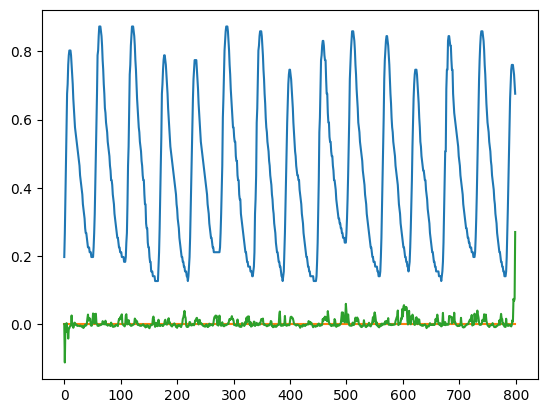

0.05309019


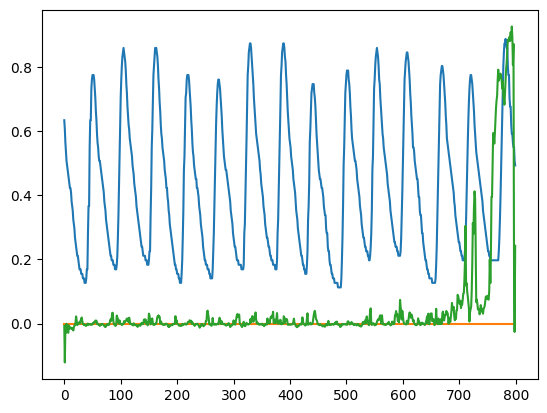

0.36891845


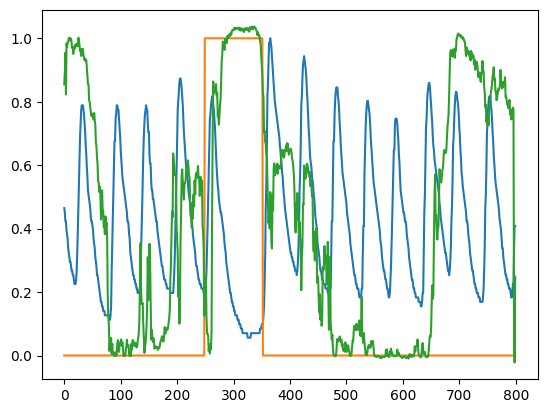

0.59322196


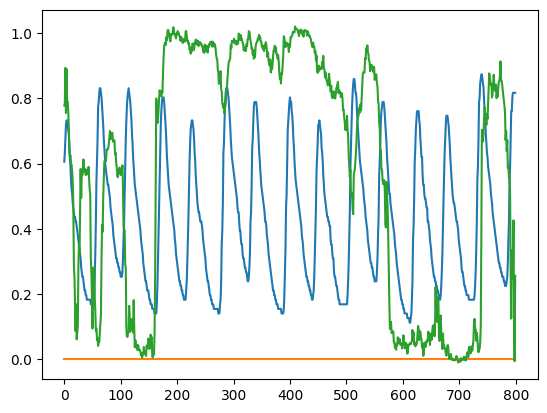

0.3321459


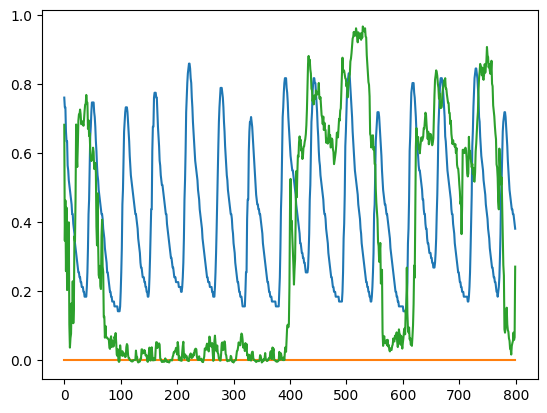

0.20292121


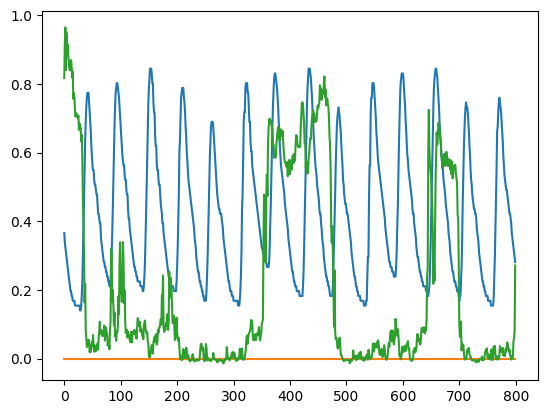

0.33524242


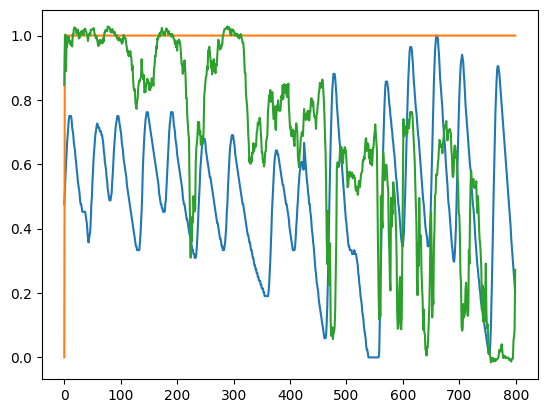

0.12899055


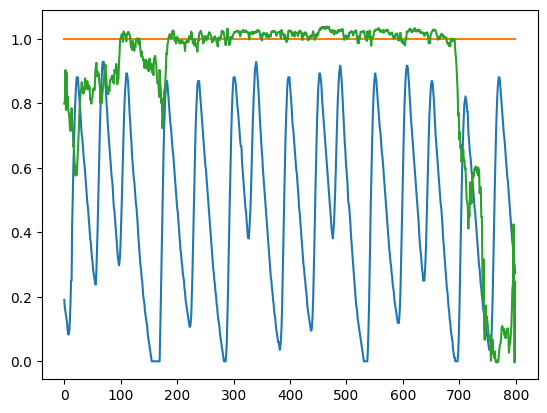

0.12564655


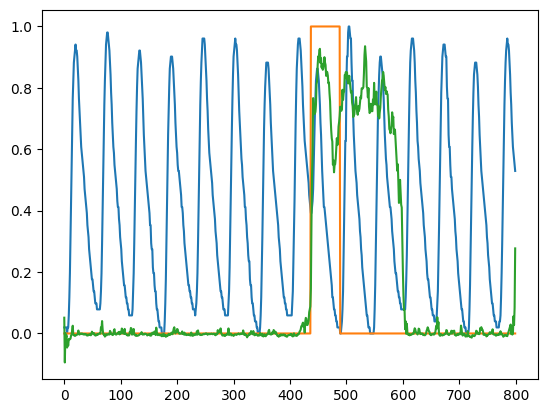

0.0057579256


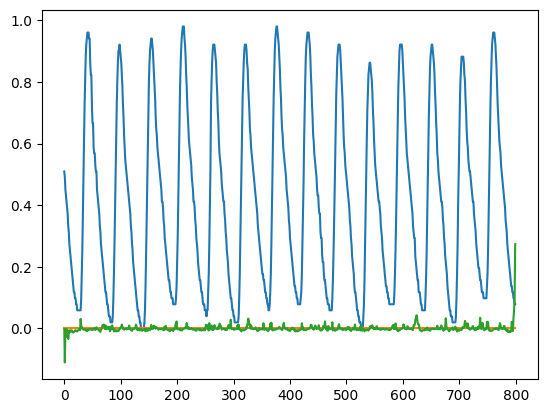

0.0055136834


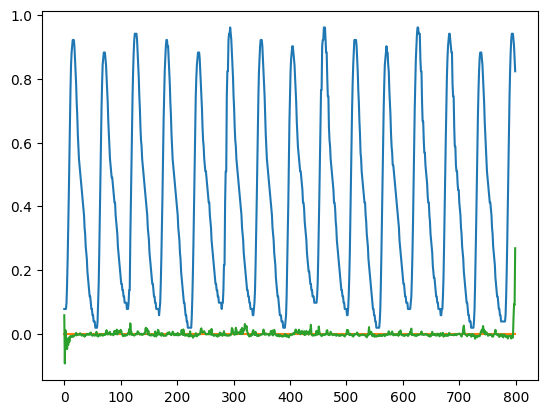

0.0400459


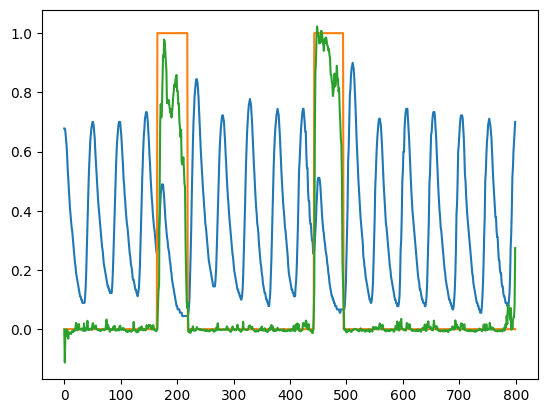

0.08172706


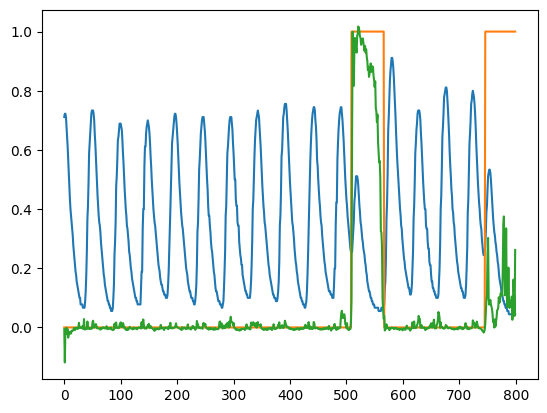

0.17652655


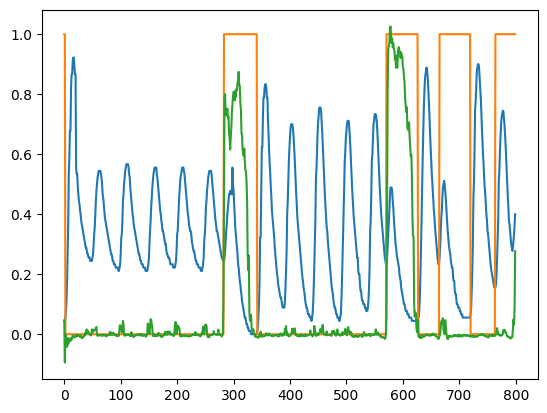

0.16756774


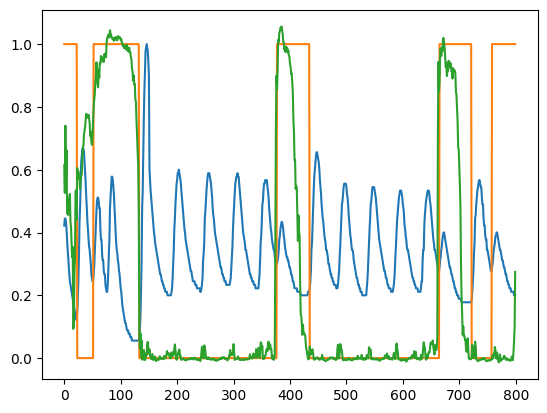

0.22801796


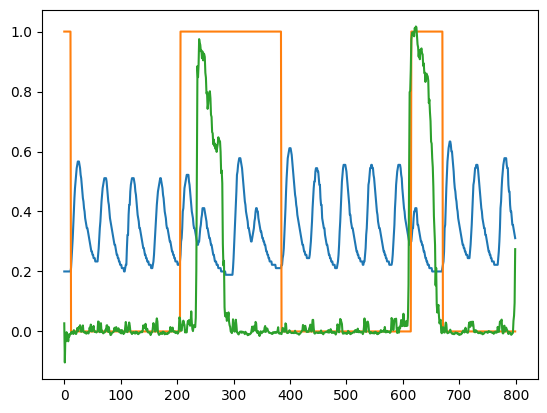

0.32496136


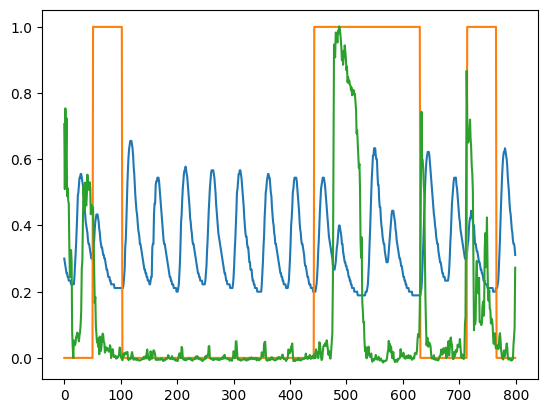

0.1278592


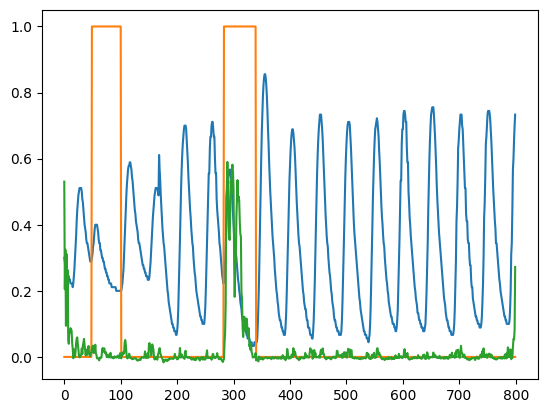

0.19965929


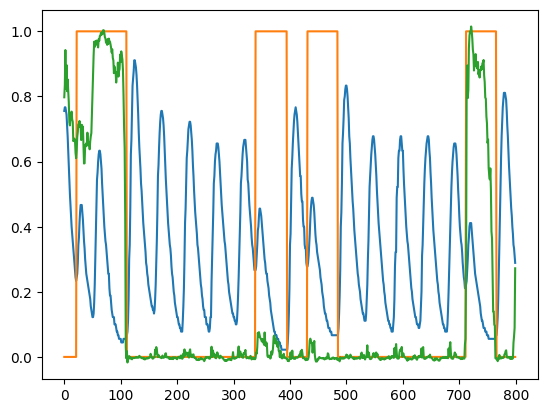

0.25111225


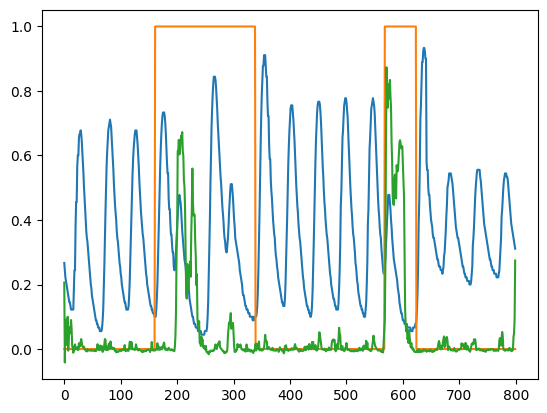

0.005024886


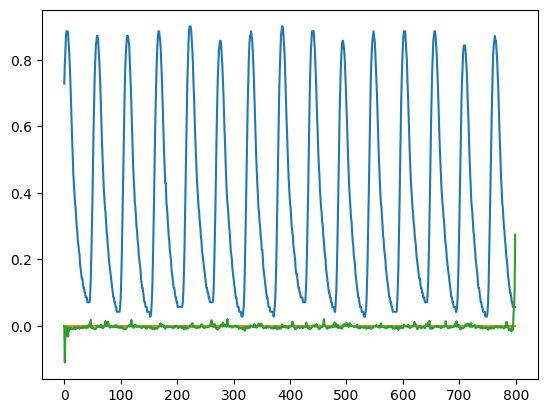

0.009673268


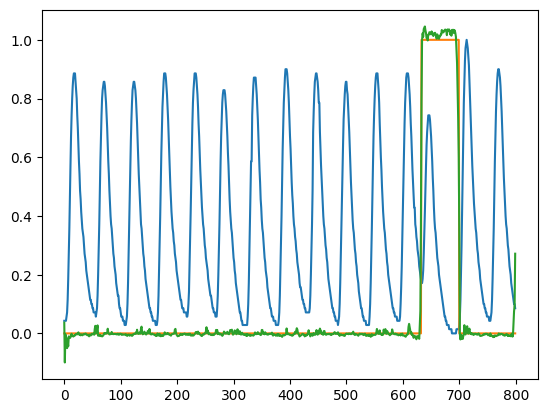

0.005249628


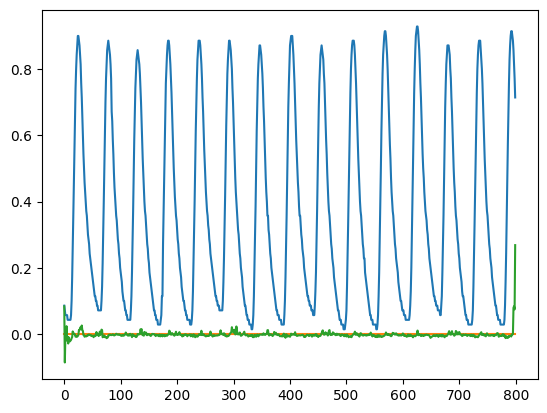

0.041079797


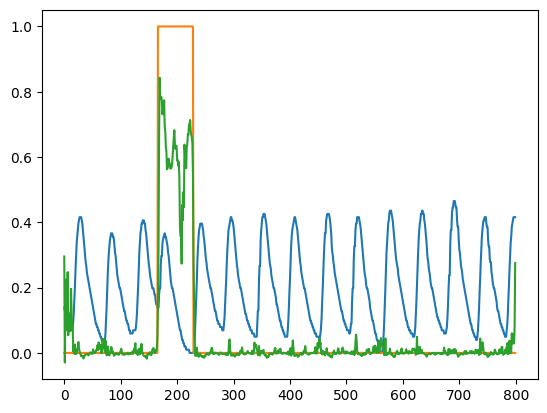

0.008493082


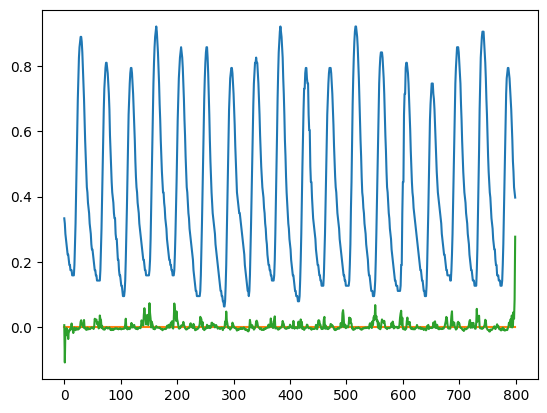

0.06381203


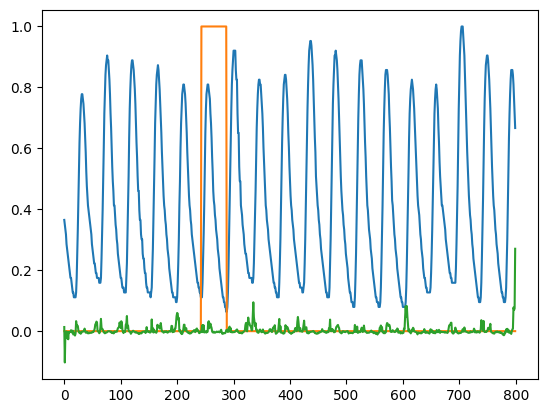

0.006671817


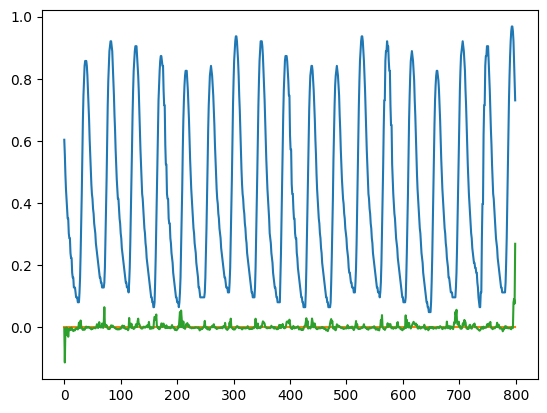

0.0057604


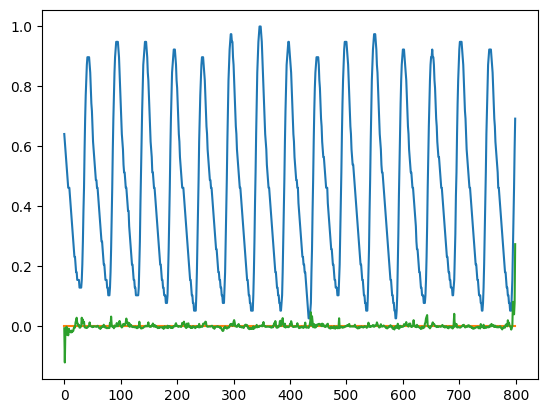

0.005959154


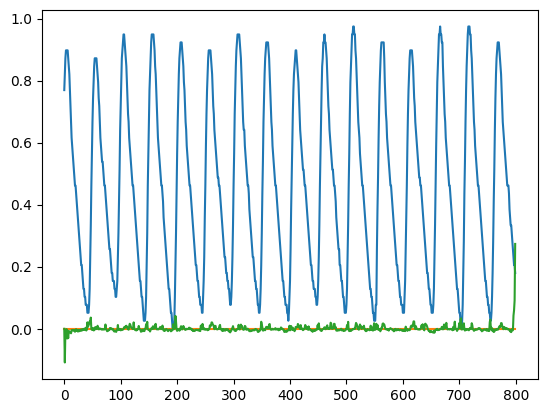

0.005854234


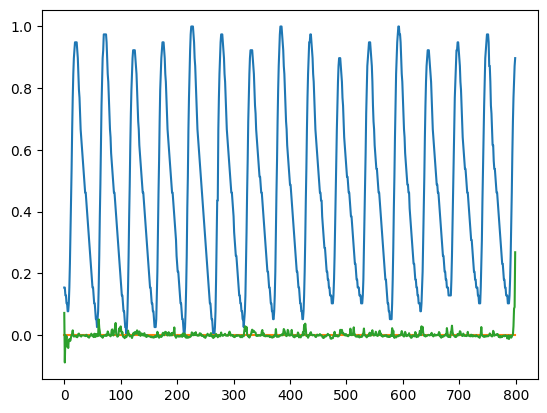

0.005972561


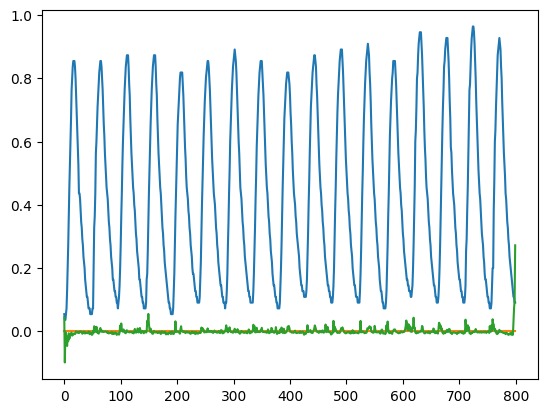

0.00553313


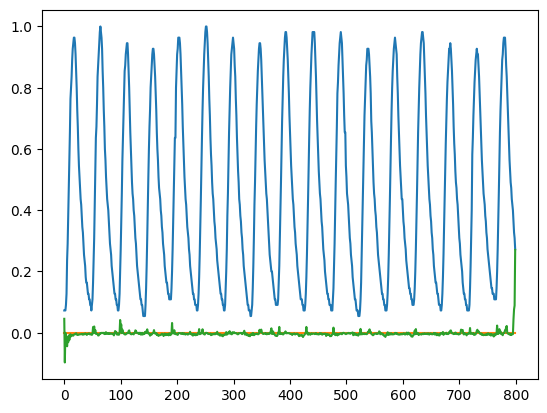

0.007879753


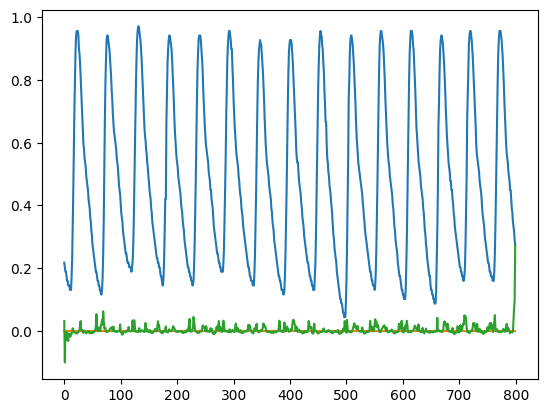

0.0074772057


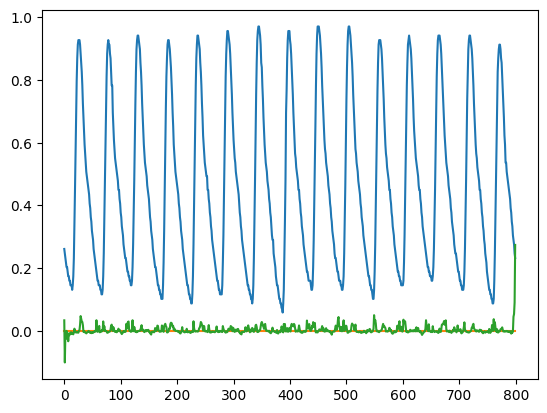

0.007759062


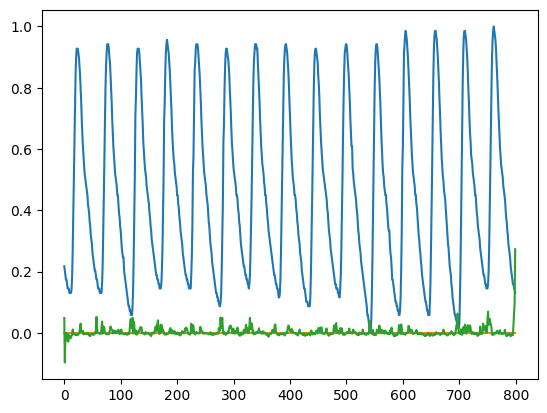

0.061621632


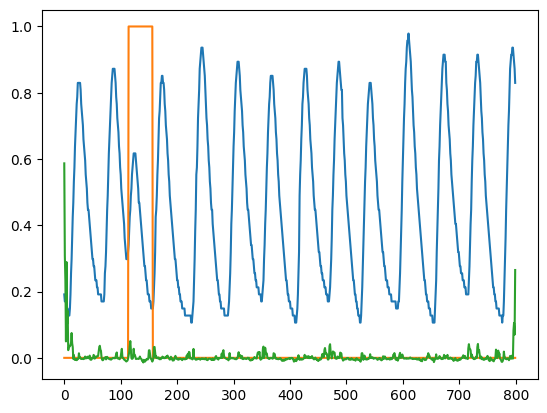

0.0072037256


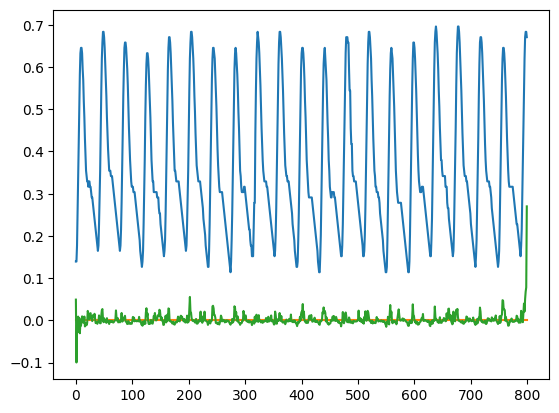

0.006503099


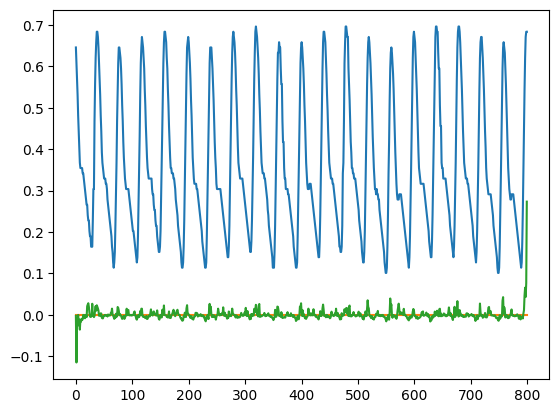

0.051648457


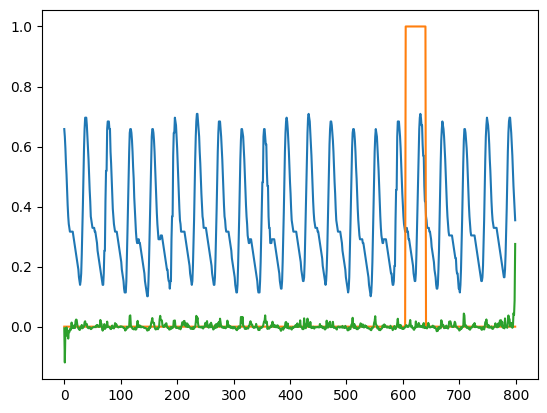

0.011465385


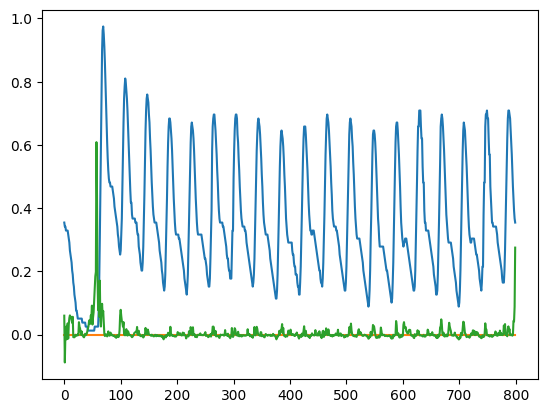

0.15423723


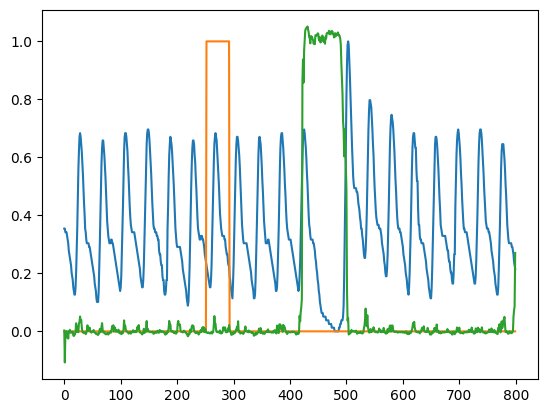

0.22971119


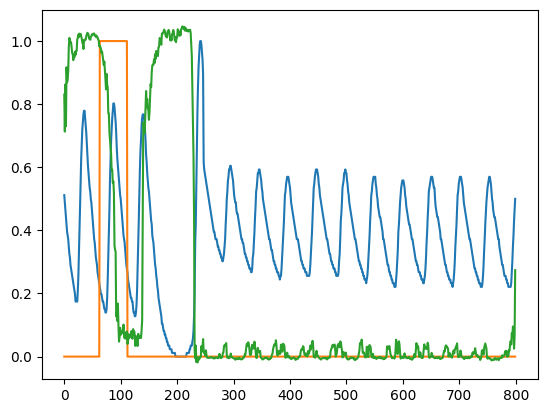

0.16882163


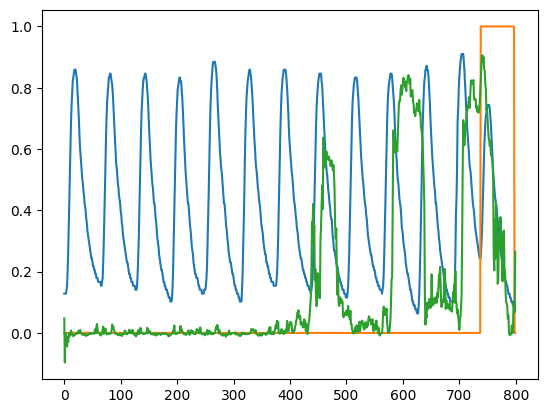

0.095302805


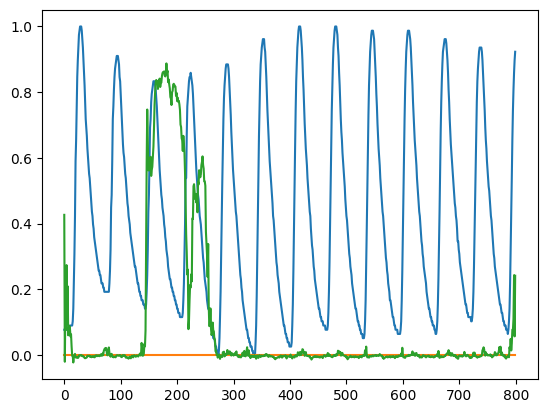

0.43441185


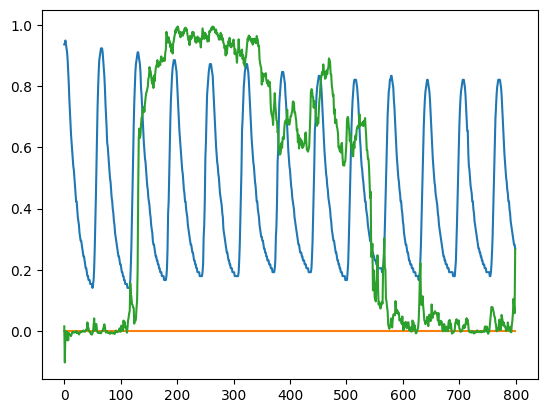

0.2371447


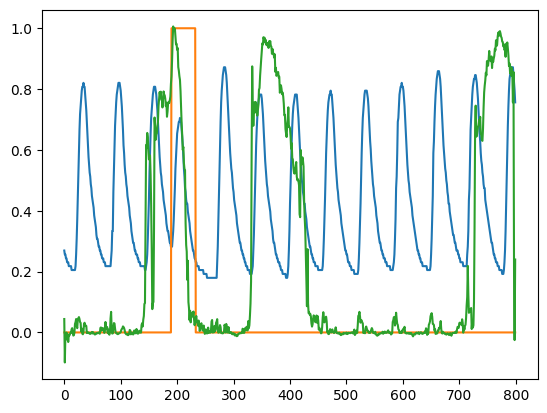

0.06922545


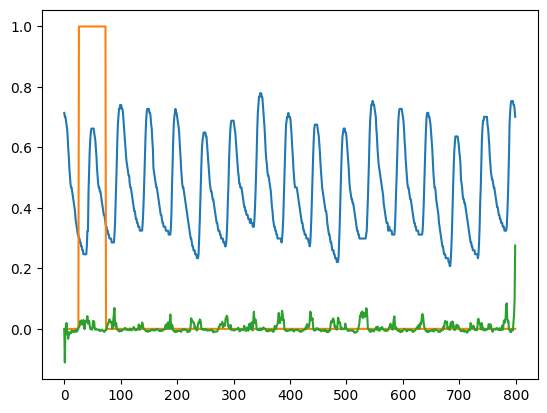

0.010045556


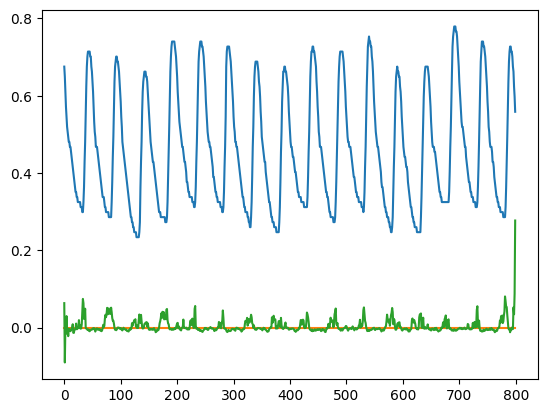

0.009584308


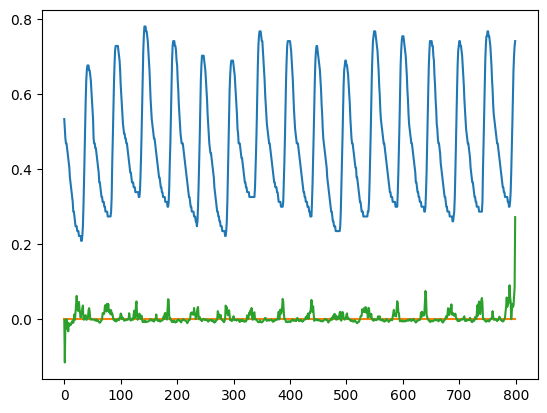

0.009154187


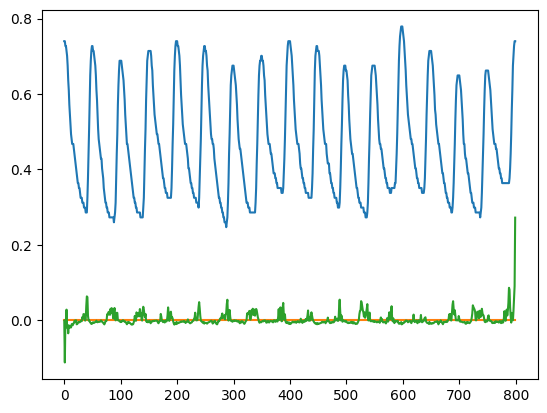

0.0073903543


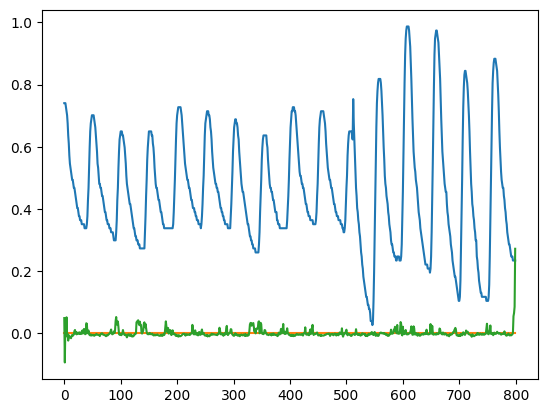

0.6777644


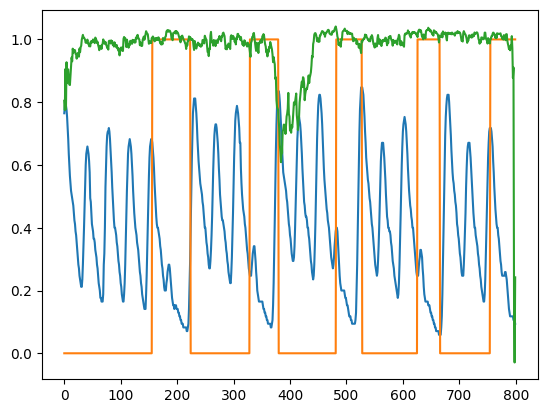

0.25552312


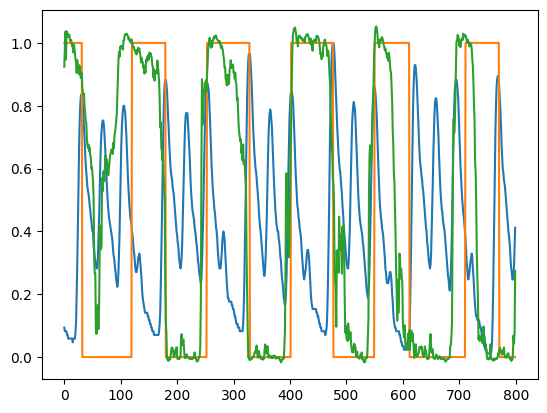

0.08282772


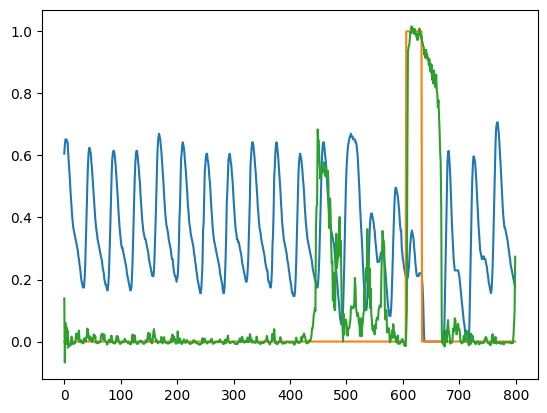

0.058046617


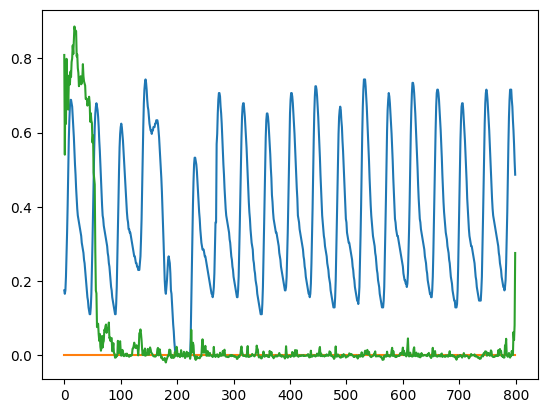

0.04075586


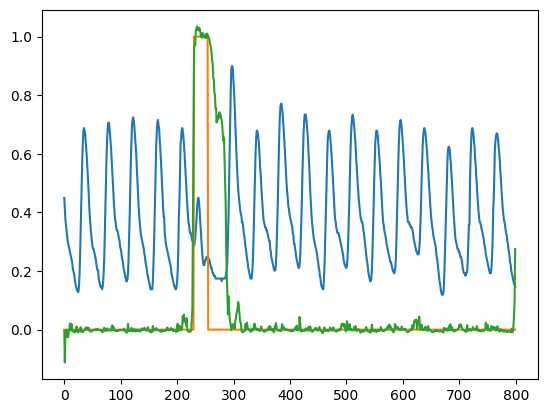

0.18499805


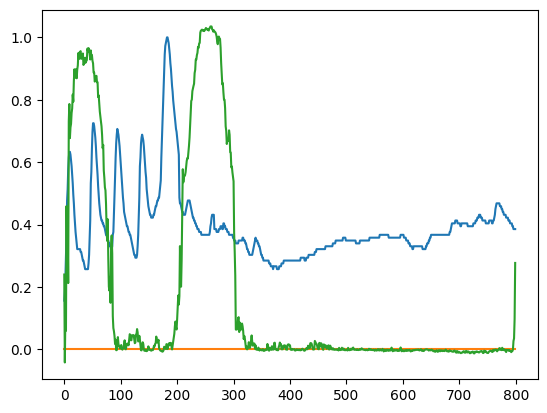

0.008511925


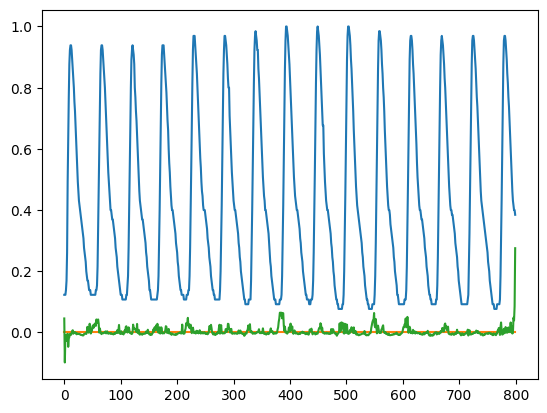

0.052364487


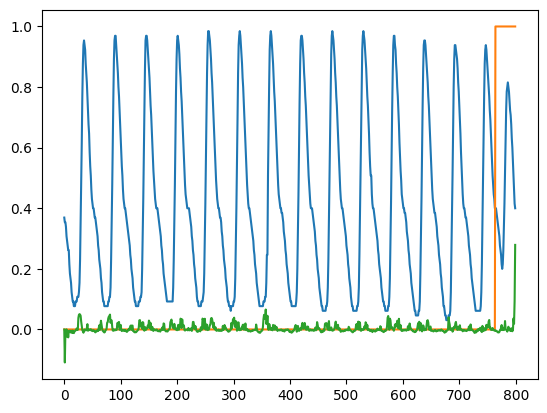

0.006478666


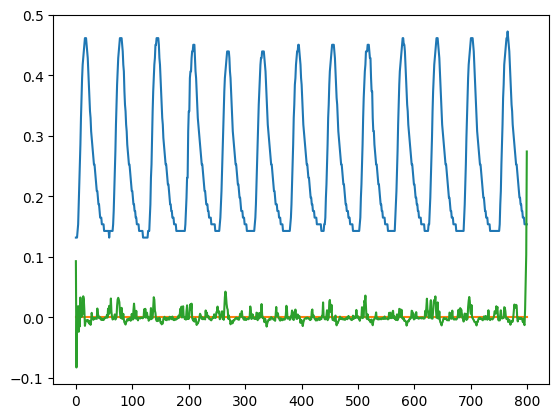

0.15038557


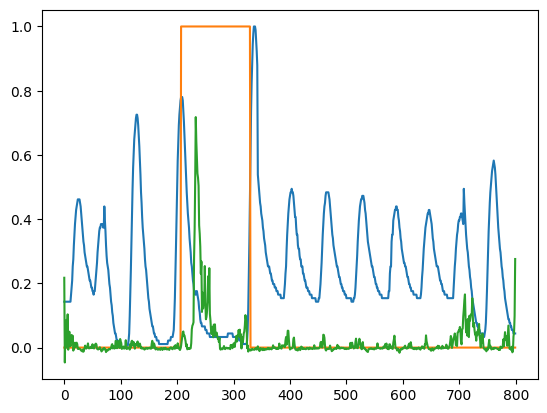

0.008770732


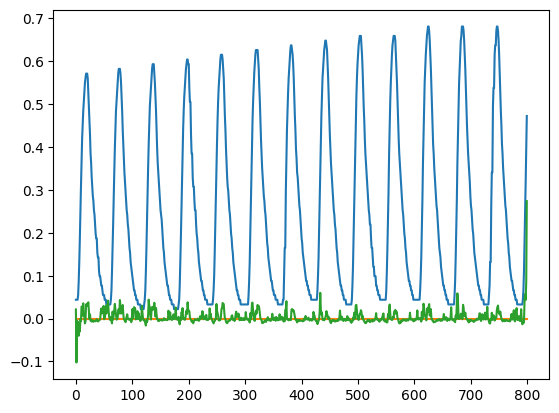

In [ ]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()